In [17]:
from langgraph.graph import StateGraph ,START,END
from typing import TypedDict


In [18]:
class BMIState(TypedDict):
    """this is the state of BMI calculator"""
    weight_kg: float
    height_m: float
    bmi: float
    health_status: str

In [19]:
graph = StateGraph(BMIState)

def calculate_bmi (state: BMIState)-> BMIState:
    """this function returns state with bmi calculated"""
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight / (height ** 2)
    state['bmi'] = bmi
    return state


In [20]:
def test_health(state:BMIState)-> BMIState:
   """this function returns the health status based on bmi"""
   bmi = state['bmi']
   if(bmi<18.5):
       state['health_status'] = 'Underweight'
   elif(bmi>=18.5 and bmi<25):
       state['health_status'] = 'Normal weight'
   else:
       state['health_status'] = 'Overweight'
   return state


In [21]:
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('test_health', test_health)

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'test_health')
graph.add_edge('test_health', END)

workflow =graph.compile()

In [22]:
initial_state = {'weight_kg': 70, 'height_m': 1.75}
final_state = workflow.invoke(initial_state)

print(final_state)  # Output: {'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.857142857142858}

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.857142857142858, 'health_status': 'Normal weight'}


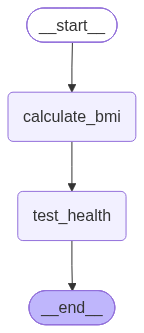

In [23]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())